In [1]:
library(dplyr)

Warning message:
“package ‘dplyr’ was built under R version 4.3.2”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [ ]:
# "indir" is a custom input path, and "outdir" is a custom output path.
# indir=""
# outdir=""

In [ ]:
CA1_path <- paste0(indir,"/04_H3K4me3_Allsubclass/CA1/")
CA1_files <- list.files(path = CA1_path, pattern = "\\.tmp$", full.names = TRUE)
CA1_files

[1] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/04_H3K4me3_Allsubclass/CA1//Paired-Tag_H3K4me3_FC_CT.mm10.tmp"     
 [2] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/04_H3K4me3_Allsubclass/CA1//Paired-Tag_H3K4me3_FC_L2_3.mm10.tmp"   
 [3] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/04_H3K4me3_Allsubclass/CA1//Paired-Tag_H3K4me3_FC_L4_Rorb.mm10.tmp"
 [4] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/04_H3K4me3_Allsubclass/CA1//Paired-Tag_H3K4me3_FC_L5.mm10.tmp"     
 [5] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/04_H3K4me3_Allsubclass/CA1//Paired-Tag_H3K4me3_FC_L6.mm10.tmp"     
 [6] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/04_H3K4me3_Allsubclass/CA1//Paired-Tag_H3K4me3_FC_NP.mm10.tmp"     
 [7] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/04_H3K4me3_Allsubclass/CA1//Paired-Tag_H3K4me3_HC_CA1.mm10.tmp"    
 [8] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/04_H3K4me3_Allsubclass/CA1//Paired-Tag_H3K4me3_HC_CA23.mm10.tmp"   
 [9] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/04_H3K4me3_Allsubclass/CA1//Paired-Tag_H3K4me3_HC_DG.mm10.tmp"     
[10] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/04_H3K4me3_Allsubclass/CA1//Paired-Tag_H3K4me3_In_CGE.mm10.tmp"    
[11] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/04_H3K4me3_Allsubclass/CA1//Paired-Tag_H3K4me3_In_Pvalb.mm10.tmp"  
[12] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/04_H3K4me3_Allsubclass/CA1//Paired-Tag_H3K4me3_In_Sst.mm10.tmp"

In [3]:
merged_CA1 <- NULL

In [4]:
gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$","\\2","Paired-Tag_H3K4me3_FC_CT.mm10.tmp")

[1] "CT"

In [5]:
gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$","\\2","Paired-Tag_H3K4me3_FC_L2_3.mm10.tmp")

[1] "L2_3"

In [6]:
gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$","\\2","Paired-Tag_H3K4me3_HC_DG.mm10.tmp")
gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$","\\2","Paired-Tag_H3K4me3_In_Pvalb.mm10.tmp")

[1] "DG"

[1] "Pvalb"

In [7]:
for (file in CA1_files) {

  base_name <- gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$", "\\2", basename(file))
  print(base_name)

  tmp_data <- read.table(file, header = TRUE, sep = "\t", stringsAsFactors = FALSE)

  if (!is.null(merged_CA1)) {
    if (!identical(merged_CA1[, 1], tmp_data[, 1])) {
      stop(paste("The first column in file", file, "is not identical to the previous files!"))
    }
  }

  colnames(tmp_data)[2:3] <- paste(base_name, colnames(tmp_data)[2:3], sep = "_")

  if (is.null(merged_CA1)) {
    merged_CA1 <- tmp_data
  } else {
    merged_CA1 <- cbind(merged_CA1, tmp_data[, -1])
  }
}

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


In [8]:
merged_CA1

hyperDHMR,CT_signal_sum,CT_signal_sum_log10,L2_3_signal_sum,L2_3_signal_sum_log10,L4_Rorb_signal_sum,L4_Rorb_signal_sum_log10,L5_signal_sum,L5_signal_sum_log10,L6_signal_sum,⋯,CA23_signal_sum,CA23_signal_sum_log10,DG_signal_sum,DG_signal_sum_log10,CGE_signal_sum,CGE_signal_sum_log10,Pvalb_signal_sum,Pvalb_signal_sum_log10,Sst_signal_sum,Sst_signal_sum_log10
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3707240-3708240,0.000000,0.0000000,0.000000,0.0000000,0.0000,0.000000,0.0000,0.000000,0.000,⋯,0.0000,0.000000,0.00000,0.000000,0.000,0.000000,0.00,0.000000,0,0
chr1:3868330-3869330,0.000000,0.0000000,0.000000,0.0000000,0.0000,0.000000,0.0000,0.000000,0.000,⋯,0.0000,0.000000,0.00000,0.000000,0.000,0.000000,0.00,0.000000,0,0
chr1:4000851-4001851,0.000000,0.0000000,0.000000,0.0000000,0.0000,0.000000,0.0000,0.000000,0.000,⋯,0.0000,0.000000,0.00000,0.000000,0.000,0.000000,0.00,0.000000,0,0
chr1:4017553-4018553,0.000000,0.0000000,0.000000,0.0000000,0.0000,0.000000,0.0000,0.000000,0.000,⋯,0.0000,0.000000,0.00000,0.000000,0.000,0.000000,0.00,0.000000,0,0
chr1:4168027-4169027,0.000000,0.0000000,0.000000,0.0000000,0.0000,0.000000,0.0000,0.000000,0.000,⋯,0.0000,0.000000,0.00000,0.000000,0.000,0.000000,0.00,0.000000,0,0
chr1:4249638-4250638,0.000000,0.0000000,0.000000,0.0000000,602.7680,2.780870,0.0000,0.000000,0.000,⋯,0.0000,0.000000,164.55115,2.218932,0.000,0.000000,0.00,0.000000,0,0
chr1:4454449-4455449,0.000000,0.0000000,0.000000,0.0000000,0.0000,0.000000,0.0000,0.000000,0.000,⋯,0.0000,0.000000,0.00000,0.000000,0.000,0.000000,0.00,0.000000,0,0
chr1:4794017-4795017,0.000000,0.0000000,8.125014,0.9602335,0.0000,0.000000,0.0000,0.000000,0.000,⋯,0.0000,0.000000,0.00000,0.000000,0.000,0.000000,0.00,0.000000,0,0
chr1:5336791-5337791,0.000000,0.0000000,0.000000,0.0000000,0.0000,0.000000,0.0000,0.000000,0.000,⋯,0.0000,0.000000,0.00000,0.000000,0.000,0.000000,0.00,0.000000,0,0


In [9]:
merged_CA1 <- merged_CA1[, c(1, grep("signal_sum_log10", colnames(merged_CA1)))]

merged_CA1

hyperDHMR,CT_signal_sum_log10,L2_3_signal_sum_log10,L4_Rorb_signal_sum_log10,L5_signal_sum_log10,L6_signal_sum_log10,NP_signal_sum_log10,CA1_signal_sum_log10,CA23_signal_sum_log10,DG_signal_sum_log10,CGE_signal_sum_log10,Pvalb_signal_sum_log10,Sst_signal_sum_log10
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3707240-3708240,0.0000000,0.0000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0
chr1:3868330-3869330,0.0000000,0.0000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0
chr1:4000851-4001851,0.0000000,0.0000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0
chr1:4017553-4018553,0.0000000,0.0000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0
chr1:4168027-4169027,0.0000000,0.0000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0
chr1:4249638-4250638,0.0000000,0.0000000,2.780870,0.000000,0.000000,0,0.000000,0.000000,2.218932,0.000000,0.000000,0
chr1:4454449-4455449,0.0000000,0.0000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0
chr1:4794017-4795017,0.0000000,0.9602335,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0
chr1:5336791-5337791,0.0000000,0.0000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0


In [10]:
library(tidyverse)

Warning message:
“package ‘tidyverse’ was built under R version 4.3.3”
Warning message:
“package ‘readr’ was built under R version 4.3.3”
Warning message:
“package ‘stringr’ was built under R version 4.3.2”
Warning message:
“package ‘forcats’ was built under R version 4.3.3”
── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ readr     2.1.5
✔ ggplot2   3.5.1     ✔ stringr   1.5.1
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     ✔ tidyr     1.3.0
── Conflicts ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [11]:
merged_CA1 <- merged_CA1 %>% column_to_rownames("hyperDHMR")
merged_CA1

,CT_signal_sum_log10,L2_3_signal_sum_log10,L4_Rorb_signal_sum_log10,L5_signal_sum_log10,L6_signal_sum_log10,NP_signal_sum_log10,CA1_signal_sum_log10,CA23_signal_sum_log10,DG_signal_sum_log10,CGE_signal_sum_log10,Pvalb_signal_sum_log10,Sst_signal_sum_log10
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3707240-3708240,0.0000000,0.0000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0
chr1:3868330-3869330,0.0000000,0.0000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0
chr1:4000851-4001851,0.0000000,0.0000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0
chr1:4017553-4018553,0.0000000,0.0000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0
chr1:4168027-4169027,0.0000000,0.0000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0
chr1:4249638-4250638,0.0000000,0.0000000,2.780870,0.000000,0.000000,0,0.000000,0.000000,2.218932,0.000000,0.000000,0
chr1:4454449-4455449,0.0000000,0.0000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0
chr1:4794017-4795017,0.0000000,0.9602335,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0
chr1:5336791-5337791,0.0000000,0.0000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0


In [12]:
colnames(merged_CA1) <- gsub("_signal_sum_log10$","",colnames(merged_CA1))
merged_CA1

,CT,L2_3,L4_Rorb,L5,L6,NP,CA1,CA23,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3707240-3708240,0.0000000,0.0000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0
chr1:3868330-3869330,0.0000000,0.0000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0
chr1:4000851-4001851,0.0000000,0.0000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0
chr1:4017553-4018553,0.0000000,0.0000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0
chr1:4168027-4169027,0.0000000,0.0000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0
chr1:4249638-4250638,0.0000000,0.0000000,2.780870,0.000000,0.000000,0,0.000000,0.000000,2.218932,0.000000,0.000000,0
chr1:4454449-4455449,0.0000000,0.0000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0
chr1:4794017-4795017,0.0000000,0.9602335,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0
chr1:5336791-5337791,0.0000000,0.0000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0


In [13]:
colnames(merged_CA1)[which(colnames(merged_CA1) %in% "L4_Rorb")] <- "L4"

In [14]:
merged_CA1

,CT,L2_3,L4,L5,L6,NP,CA1,CA23,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3707240-3708240,0.0000000,0.0000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0
chr1:3868330-3869330,0.0000000,0.0000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0
chr1:4000851-4001851,0.0000000,0.0000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0
chr1:4017553-4018553,0.0000000,0.0000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0
chr1:4168027-4169027,0.0000000,0.0000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0
chr1:4249638-4250638,0.0000000,0.0000000,2.780870,0.000000,0.000000,0,0.000000,0.000000,2.218932,0.000000,0.000000,0
chr1:4454449-4455449,0.0000000,0.0000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0
chr1:4794017-4795017,0.0000000,0.9602335,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0
chr1:5336791-5337791,0.0000000,0.0000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0


In [15]:
merged_CA1$merge_L5 <- (merged_CA1$L5+merged_CA1$L6)/2
merged_CA1 <- merged_CA1 %>% dplyr::select(-c(L5,L6))
colnames(merged_CA1)[which(colnames(merged_CA1) == "merge_L5")] <- "L5"
merged_CA1

,CT,L2_3,L4,NP,CA1,CA23,DG,CGE,Pvalb,Sst,L5
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3707240-3708240,0.0000000,0.0000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000
chr1:3868330-3869330,0.0000000,0.0000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000
chr1:4000851-4001851,0.0000000,0.0000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000
chr1:4017553-4018553,0.0000000,0.0000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000
chr1:4168027-4169027,0.0000000,0.0000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000
chr1:4249638-4250638,0.0000000,0.0000000,2.780870,0,0.000000,0.000000,2.218932,0.000000,0.000000,0,0.000000
chr1:4454449-4455449,0.0000000,0.0000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000
chr1:4794017-4795017,0.0000000,0.9602335,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000
chr1:5336791-5337791,0.0000000,0.0000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000


In [16]:
# celltype_order <- c("L2_3","L4","L5","L6","CA1","CA23","NP","CT","DG","CGE","Pvalb","Sst")
celltype_order <- c("L2_3","L4","L5","CA1","CA23","NP","CT","DG","CGE","Pvalb","Sst")
celltype_order

[1] "L2_3"  "L4"    "L5"    "CA1"   "CA23"  "NP"    "CT"    "DG"    "CGE"  
[10] "Pvalb" "Sst"

In [17]:
merged_CA1 <- merged_CA1[,celltype_order]
merged_CA1

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3707240-3708240,0.0000000,0.000000,0.000000,0.000000,0.000000,0,0.0000000,0.000000,0.000000,0.000000,0
chr1:3868330-3869330,0.0000000,0.000000,0.000000,0.000000,0.000000,0,0.0000000,0.000000,0.000000,0.000000,0
chr1:4000851-4001851,0.0000000,0.000000,0.000000,0.000000,0.000000,0,0.0000000,0.000000,0.000000,0.000000,0
chr1:4017553-4018553,0.0000000,0.000000,0.000000,0.000000,0.000000,0,0.0000000,0.000000,0.000000,0.000000,0
chr1:4168027-4169027,0.0000000,0.000000,0.000000,0.000000,0.000000,0,0.0000000,0.000000,0.000000,0.000000,0
chr1:4249638-4250638,0.0000000,2.780870,0.000000,0.000000,0.000000,0,0.0000000,2.218932,0.000000,0.000000,0
chr1:4454449-4455449,0.0000000,0.000000,0.000000,0.000000,0.000000,0,0.0000000,0.000000,0.000000,0.000000,0
chr1:4794017-4795017,0.9602335,0.000000,0.000000,0.000000,0.000000,0,0.0000000,0.000000,0.000000,0.000000,0
chr1:5336791-5337791,0.0000000,0.000000,0.000000,0.000000,0.000000,0,0.0000000,0.000000,0.000000,0.000000,0


In [18]:
colMeans(merged_CA1) %>% data.frame() %>% t()

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
.,0.2974274,0.2441377,0.147525,0.2964708,0.315603,0.0494591,0.1959652,0.5580967,0.135869,0.09138013,0.1299602


In [19]:
process_files <- function(input_path, pattern = "\\.tmp$", celltype_order) {
  files <- list.files(path = input_path, pattern = pattern, full.names = TRUE)
  merged_data <- NULL

  for (file in files) {
    base_name <- gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$", "\\2", basename(file))
    print(base_name)

    tmp_data <- read.table(file, header = TRUE, sep = "\t", stringsAsFactors = FALSE)

    if (!is.null(merged_data)) {
      if (!identical(merged_data[, 1], tmp_data[, 1])) {
        stop(paste("The first column in file", file, "is not identical to the previous files!"))
      }
    }

    colnames(tmp_data)[2:3] <- paste(base_name, colnames(tmp_data)[2:3], sep = "_")

    if (is.null(merged_data)) {
      merged_data <- tmp_data
    } else {
      merged_data <- cbind(merged_data, tmp_data[, -1])
    }
  }

  merged_data <- merged_data[, c(1, grep("signal_sum_log10", colnames(merged_data)))]
  merged_data <- merged_data %>% column_to_rownames("hyperDHMR")
  colnames(merged_data) <- gsub("_signal_sum_log10$", "", colnames(merged_data))

  colnames(merged_data)[which(colnames(merged_data) %in% "L4_Rorb")] <- "L4"

  merged_data$merge_L5 <- (merged_data$L5+merged_data$L6)/2
  merged_data <- merged_data %>% dplyr::select(-c(L5,L6))
  colnames(merged_data)[which(colnames(merged_data) == "merge_L5")] <- "L5"

  celltype_order <- c("L2_3", "L4", "L5", "CA1", "CA23", "NP", "CT", "DG", "CGE", "Pvalb", "Sst")

  merged_data <- merged_data[, celltype_order]
  
  return(merged_data)
}

In [ ]:
H3K4me3_path <- paste0(indir,"/04_H3K4me3_Allsubclass/")

In [21]:
subdirs <- list.dirs(path = H3K4me3_path, full.names = TRUE, recursive = FALSE)
subdirs

[1] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/04_H3K4me3_Allsubclass//CA1"  
 [2] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/04_H3K4me3_Allsubclass//CA23" 
 [3] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/04_H3K4me3_Allsubclass//CT"   
 [4] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/04_H3K4me3_Allsubclass//DG"   
 [5] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/04_H3K4me3_Allsubclass//L2_3" 
 [6] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/04_H3K4me3_Allsubclass//L4_5" 
 [7] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/04_H3K4me3_Allsubclass//L5"   
 [8] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/04_H3K4me3_Allsubclass//Lamp5"
 [9] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/04_H3K4me3_Allsubclass//NP"   
[10] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/04_H3K4me3_Allsubclass//Pvalb"
[11] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/04_H3K4me3_Allsubclass//Sncg" 
[12] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/04_H3K4me3_Allsubclass//Sst"

In [22]:
basename(subdirs)

[1] "CA1"   "CA23"  "CT"    "DG"    "L2_3"  "L4_5"  "L5"    "Lamp5" "NP"   
[10] "Pvalb" "Sncg"  "Sst"

In [ ]:
L2_3 <- process_files(paste0(indir,'/04_H3K4me3_Allsubclass/L2_3'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

L2_3

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:40205252-40206252,0.000000,0.000000,0.0000000,0.000000,2.533847,0,2.225138,2.378471,2.838909,0.000000,0.0000
chr1:63801436-63802436,0.000000,0.000000,0.0000000,0.000000,0.000000,0,1.500528,0.000000,0.000000,0.000000,0.0000
chr1:95910578-95911578,0.000000,0.000000,0.0000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.0000
chr1:121992418-121993418,0.000000,0.000000,0.0000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.0000
chr1:123860055-123861055,1.352325,0.000000,0.8449466,2.802619,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.0000
chr1:127035082-127036082,0.000000,0.000000,0.0000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.0000
chr1:165699424-165700424,0.000000,0.000000,0.0000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.0000
chr1:184865166-184866166,0.000000,0.000000,0.7432266,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.0000
chr2:10595247-10596247,0.000000,0.000000,0.0000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.0000


In [24]:
L2_3_mean <- colMeans(L2_3) %>% data.frame() %>% t()
rownames(L2_3_mean) <- "L2_3"
L2_3_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L2_3,0.3590057,0.3504563,0.1450121,0.2980304,0.2711452,0,0.2221787,0.548348,0.1673953,0.1338484,0.1125983


In [ ]:
L4_5 <- process_files(paste0(indir,'/04_H3K4me3_Allsubclass/L4_5'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

L4_5

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3989606-3990606,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.00000,0.000000,0.000000,0.000000,0
chr1:7536517-7537517,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.00000,2.302543,0.000000,0.000000,0
chr1:9780815-9781815,0.000000,0.000000,0.000000,3.221215,0.000000,0,0.00000,0.000000,0.000000,0.000000,0
chr1:14839073-14840073,0.000000,0.000000,1.621047,0.000000,0.000000,0,0.00000,0.000000,0.000000,0.000000,0
chr1:14914779-14915779,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.00000,0.000000,0.000000,0.000000,0
chr1:17756423-17757423,0.000000,2.653854,0.000000,0.000000,0.000000,0,0.00000,0.000000,0.000000,0.000000,0
chr1:22023298-22024298,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.00000,0.000000,0.000000,0.000000,0
chr1:23137109-23138109,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.00000,1.987909,0.000000,0.000000,0
chr1:26269966-26270966,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.00000,0.000000,3.063409,0.000000,0


In [26]:
L4_5_mean <- colMeans(L4_5) %>% data.frame() %>% t()
rownames(L4_5_mean) <- "L4_5"
L4_5_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L4_5,0.3412078,0.306033,0.1854657,0.273846,0.2916608,0.07033238,0.1959845,0.4948336,0.1481591,0.1248976,0.1309753


In [ ]:
L5 <- process_files(paste0(indir,'/04_H3K4me3_Allsubclass/L5'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

L5

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4185672-4186672,0.0000000,0.000000,0,0.000000,0.000000,0,0,0.000000,0,0.000000,0.000000
chr1:9994550-9995550,0.0000000,0.000000,0,0.000000,0.000000,0,0,0.000000,0,0.000000,0.000000
chr1:20083023-20084023,0.0000000,0.000000,0,0.000000,0.000000,0,0,0.000000,0,0.000000,0.000000
chr1:22220457-22221457,0.0000000,0.000000,0,0.000000,0.000000,0,0,0.000000,0,0.000000,0.000000
chr1:25591789-25592789,0.0000000,0.000000,0,0.000000,0.000000,0,0,0.000000,0,0.000000,0.000000
chr1:26496284-26497284,0.0000000,0.000000,0,0.000000,0.000000,0,0,0.000000,0,0.000000,0.000000
chr1:27086331-27087331,0.0000000,0.000000,0,0.000000,0.000000,0,0,0.000000,0,0.000000,0.000000
chr1:27631906-27632906,0.0000000,0.000000,0,0.000000,0.000000,0,0,0.000000,0,0.000000,0.000000
chr1:27648468-27649468,0.0000000,0.000000,0,0.000000,0.000000,0,0,0.000000,0,0.000000,0.000000


In [28]:
L5_mean <- colMeans(L5) %>% data.frame() %>% t()
rownames(L5_mean) <- "L5"
L5_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L5,0.3251297,0.2631506,0.1766561,0.3607558,0.3581245,0.04719568,0.2088531,0.5432667,0.2280409,0.1453163,0.1586566


In [ ]:
CA1 <- process_files(paste0(indir,'/04_H3K4me3_Allsubclass/CA1'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

CA1

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3707240-3708240,0.0000000,0.000000,0.000000,0.000000,0.000000,0,0.0000000,0.000000,0.000000,0.000000,0
chr1:3868330-3869330,0.0000000,0.000000,0.000000,0.000000,0.000000,0,0.0000000,0.000000,0.000000,0.000000,0
chr1:4000851-4001851,0.0000000,0.000000,0.000000,0.000000,0.000000,0,0.0000000,0.000000,0.000000,0.000000,0
chr1:4017553-4018553,0.0000000,0.000000,0.000000,0.000000,0.000000,0,0.0000000,0.000000,0.000000,0.000000,0
chr1:4168027-4169027,0.0000000,0.000000,0.000000,0.000000,0.000000,0,0.0000000,0.000000,0.000000,0.000000,0
chr1:4249638-4250638,0.0000000,2.780870,0.000000,0.000000,0.000000,0,0.0000000,2.218932,0.000000,0.000000,0
chr1:4454449-4455449,0.0000000,0.000000,0.000000,0.000000,0.000000,0,0.0000000,0.000000,0.000000,0.000000,0
chr1:4794017-4795017,0.9602335,0.000000,0.000000,0.000000,0.000000,0,0.0000000,0.000000,0.000000,0.000000,0
chr1:5336791-5337791,0.0000000,0.000000,0.000000,0.000000,0.000000,0,0.0000000,0.000000,0.000000,0.000000,0


In [30]:
CA1_mean <- colMeans(CA1) %>% data.frame() %>% t()
rownames(CA1_mean) <- "CA1"
CA1_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
CA1,0.2974274,0.2441377,0.147525,0.2964708,0.315603,0.0494591,0.1959652,0.5580967,0.135869,0.09138013,0.1299602


In [ ]:
CA23 <- process_files(paste0(indir,'/04_H3K4me3_Allsubclass/CA23'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

CA23

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3151305-3152305,0.000000,0,0.000000,0,0.000000,0,0,0.000000,0.000000,0,0
chr1:3776523-3777523,0.000000,0,0.000000,0,0.000000,0,0,0.000000,0.000000,0,0
chr1:4031436-4032436,0.000000,0,0.000000,0,0.000000,0,0,0.000000,0.000000,0,0
chr1:4057009-4058009,0.000000,0,0.000000,0,0.000000,0,0,0.000000,0.000000,0,0
chr1:4065207-4066207,0.000000,0,0.000000,0,0.000000,0,0,0.000000,0.000000,0,0
chr1:4072107-4073107,0.000000,0,0.000000,0,0.000000,0,0,1.764278,0.000000,0,0
chr1:4118129-4119129,0.000000,0,0.000000,0,0.000000,0,0,2.182903,0.000000,0,0
chr1:4149321-4150321,0.000000,0,0.000000,0,0.000000,0,0,0.000000,0.000000,0,0
chr1:4342915-4343915,0.000000,0,0.000000,0,0.000000,0,0,0.000000,0.000000,0,0


In [32]:
CA23_mean <- colMeans(CA23) %>% data.frame() %>% t()
rownames(CA23_mean) <- "CA23"
CA23_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
CA23,0.3332319,0.2815796,0.1783403,0.2984153,0.3589137,0.05696919,0.2157394,0.5819517,0.1872712,0.1290475,0.162452


In [ ]:
NP <- process_files(paste0(indir,'/04_H3K4me3_Allsubclass/NP'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

NP

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4035689-4036689,0.000000,0.000000,0.000000,0,0.000000,0,0.000000,0.000000,0.00000,0.00000,0.000000
chr1:4933311-4934311,2.980860,0.000000,0.000000,0,0.000000,0,0.000000,0.000000,0.00000,0.00000,0.000000
chr1:6077804-6078804,0.000000,0.000000,0.000000,0,0.000000,0,0.000000,0.000000,0.00000,0.00000,0.000000
chr1:6367459-6368459,0.000000,0.000000,0.000000,0,0.000000,0,0.000000,0.000000,0.00000,0.00000,0.000000
chr1:7734392-7735392,2.680284,0.000000,0.000000,0,2.758087,0,0.000000,0.000000,0.00000,0.00000,0.000000
chr1:9367457-9368457,0.000000,0.000000,0.000000,0,0.000000,0,0.000000,0.000000,0.00000,0.00000,0.000000
chr1:9905254-9906254,3.492696,2.565237,3.150478,0,0.000000,0,0.000000,1.353481,0.00000,0.00000,0.000000
chr1:10079108-10080108,0.000000,0.000000,0.000000,0,0.000000,0,0.000000,0.000000,0.00000,0.00000,0.000000
chr1:10298443-10299443,0.000000,0.000000,0.000000,0,0.000000,0,0.000000,0.000000,0.00000,0.00000,0.000000


In [34]:
NP_mean <- colMeans(NP) %>% data.frame() %>% t()
rownames(NP_mean) <- "NP"
NP_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
NP,0.4416238,0.3625664,0.2365982,0.3420905,0.3852968,0.0818883,0.2891616,0.6840137,0.2388937,0.1801268,0.2042799


In [ ]:
CT <- process_files(paste0(indir,'/04_H3K4me3_Allsubclass/CT'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

CT

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3908393-3909393,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0
chr1:5417353-5418353,0.000000,0.000000,0.0000000,0.000000,2.758087,0.000000,0.000000,0.0000000,0.000000,0.000000,0
chr1:5957907-5958907,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,2.4183101,0.000000,0.000000,0
chr1:9594969-9595969,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0
chr1:11620744-11621744,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,2.4554082,0.000000,0.000000,0
chr1:11728492-11729492,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0
chr1:20849555-20850555,2.933947,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,1.5904252,0.000000,0.000000,0
chr1:20922610-20923610,2.680284,0.000000,0.0000000,3.134317,3.594396,0.000000,0.000000,0.6984451,1.099060,0.000000,0
chr1:23933700-23934700,3.235931,0.000000,0.9727604,2.672525,0.000000,0.000000,4.044270,3.0715942,0.000000,3.577496,0


In [36]:
CT_mean <- colMeans(CT) %>% data.frame() %>% t()
rownames(CT_mean) <- "CT"
CT_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
CT,0.3889618,0.3021477,0.1918799,0.2613862,0.2958036,0.06386445,0.2840981,0.5764319,0.1991015,0.1225173,0.1450274


In [ ]:
DG <- process_files(paste0(indir,'/04_H3K4me3_Allsubclass/DG'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

DG

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:5012521-5013521,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
chr1:6862606-6863606,0.000000,1.835754,1.470533,2.827149,0.000000,0.000000,0.00000,1.801443,0.000000,0.000000,0.000000
chr1:7358520-7359520,0.000000,0.000000,1.470533,0.000000,0.000000,0.000000,0.00000,2.778219,0.000000,0.000000,0.000000
chr1:13910825-13911825,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
chr1:16814367-16815367,0.000000,2.583374,0.000000,0.000000,0.000000,0.000000,0.00000,2.523872,0.000000,0.000000,0.000000
chr1:17029988-17030988,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,2.597260,0.000000,0.000000,0.000000
chr1:17078363-17079363,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
chr1:19954555-19955555,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
chr1:27743954-27744954,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,2.602490,0.000000,0.000000,0.000000


In [38]:
DG_mean <- colMeans(DG) %>% data.frame() %>% t()
rownames(DG_mean) <- "DG"
DG_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
DG,0.3782211,0.3312223,0.1946164,0.365031,0.3744044,0.09502283,0.2280872,0.7859492,0.1674191,0.1602022,0.1816936


In [ ]:
Lamp5 <- process_files(paste0(indir,'/04_H3K4me3_Allsubclass/Lamp5'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

Lamp5

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3033026-3034026,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0,0
chr1:3116806-3117806,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0,0
chr1:3235621-3236621,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000,1.761283,0.000000,0,0
chr1:3290843-3291843,3.077332,2.917713,1.446161,2.921145,2.376159,0,0.000000,0.000000,0.000000,0,0
chr1:3510333-3511333,0.000000,0.000000,0.000000,2.765768,0.000000,0,0.000000,0.000000,0.000000,0,0
chr1:3802417-3803417,1.609265,0.000000,0.000000,0.000000,0.000000,0,0.000000,1.244894,0.000000,0,0
chr1:3889972-3890972,0.000000,0.000000,0.000000,2.827149,0.000000,0,0.000000,0.000000,0.000000,0,0
chr1:4330502-4331502,0.000000,0.000000,0.000000,2.779533,0.000000,0,0.000000,0.000000,0.000000,0,0
chr1:4344260-4345260,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0,0


In [40]:
Lamp5_mean <- colMeans(Lamp5) %>% data.frame() %>% t()
rownames(Lamp5_mean) <- "Lamp5"
Lamp5_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
Lamp5,0.2881226,0.236514,0.1575692,0.2368294,0.2776246,0.05066039,0.1865779,0.470243,0.1745285,0.1142661,0.1221616


In [ ]:
Sncg <- process_files(paste0(indir,'/04_H3K4me3_Allsubclass/Sncg'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

Sncg

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3239626-3240626,1.560716,0.000000,0.000000,0.000000,2.154832,0.0000,0.000000,0.000000,0.000000,0,0.000000
chr1:3597956-3598956,1.443494,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,2.960036,0,0.000000
chr1:3845937-3846937,0.000000,0.000000,0.000000,2.070757,2.002221,0.0000,2.804870,1.553245,0.000000,0,0.000000
chr1:7206724-7207724,3.370111,3.252271,0.000000,2.827149,0.000000,0.0000,0.000000,0.000000,0.000000,0,0.000000
chr1:7289662-7290662,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0,0.000000
chr1:7546590-7547590,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0,0.000000
chr1:7550117-7551117,0.000000,0.000000,0.000000,0.000000,0.000000,3.6297,0.000000,0.000000,0.000000,0,0.000000
chr1:7583286-7584286,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0,0.000000
chr1:7777255-7778255,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0,0.000000


In [42]:
Sncg_mean <- colMeans(Sncg) %>% data.frame() %>% t()
rownames(Sncg_mean) <- "Sncg"
Sncg_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
Sncg,0.4057065,0.3438911,0.2254322,0.3434334,0.3588797,0.08898476,0.2678358,0.5741763,0.258153,0.1655426,0.1827539


In [43]:
rownames(Lamp5_mean) <- "CGE"
rownames(Sncg_mean) <- "CGE"
Lamp5_mean;Sncg_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
CGE,0.2881226,0.236514,0.1575692,0.2368294,0.2776246,0.05066039,0.1865779,0.470243,0.1745285,0.1142661,0.1221616


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
CGE,0.4057065,0.3438911,0.2254322,0.3434334,0.3588797,0.08898476,0.2678358,0.5741763,0.258153,0.1655426,0.1827539


In [44]:
identical(rownames(Lamp5_mean),rownames(Sncg_mean))
identical(colnames(Lamp5_mean),colnames(Sncg_mean))

[1] TRUE

[1] TRUE

In [45]:
CGE_mean <- (Lamp5_mean+Sncg_mean)/2
CGE_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
CGE,0.3469145,0.2902026,0.1915007,0.2901314,0.3182522,0.06982258,0.2272068,0.5222096,0.2163407,0.1399043,0.1524578


In [ ]:
Pvalb <- process_files(paste0(indir,'/04_H3K4me3_Allsubclass/Pvalb'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

Pvalb

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3168678-3169678,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000,2.141112,0,0.00000,0.000000
chr1:3188267-3189267,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0,0.00000,0.000000
chr1:3189154-3190154,0.000000,0.000000,0.000000,0.000000,0.000000,0,2.250796,0.000000,0,0.00000,0.000000
chr1:3229735-3230735,0.000000,0.000000,0.000000,0.000000,0.000000,0,2.564940,0.000000,0,0.00000,0.000000
chr1:3257828-3258828,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0,0.00000,0.000000
chr1:3275051-3276051,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0,3.05633,0.000000
chr1:3277592-3278592,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0,0.00000,0.000000
chr1:3343546-3344546,2.680284,0.000000,1.458493,0.000000,0.000000,0,0.000000,0.000000,0,0.00000,0.000000
chr1:3345473-3346473,0.000000,0.000000,0.000000,0.000000,2.708543,0,0.000000,0.000000,0,0.00000,0.000000


In [47]:
Pvalb_mean <- colMeans(Pvalb) %>% data.frame() %>% t()
rownames(Pvalb_mean) <- "Pvalb"
Pvalb_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
Pvalb,0.3177735,0.2662517,0.1706363,0.2619442,0.2989449,0.05992462,0.2044091,0.5172492,0.1841364,0.1174107,0.1394744


In [ ]:
Sst <- process_files(paste0(indir,'/04_H3K4me3_Allsubclass/Sst'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

Sst

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3074178-3075178,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.235381,0.000000,0,0.000000
chr1:3083989-3084989,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000
chr1:3091016-3092016,2.680284,0.000000,1.751380,0.000000,0.000000,0.000000,0.000000,2.264637,0.000000,0,0.000000
chr1:3096626-3097626,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000
chr1:3098325-3099325,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000
chr1:3104126-3105126,0.000000,0.000000,0.000000,0.000000,2.758087,0.000000,0.000000,0.000000,0.000000,0,0.000000
chr1:3105267-3106267,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.157752,0.000000,0,0.000000
chr1:3133078-3134078,0.000000,0.000000,1.465709,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,2.351087
chr1:3135638-3136638,0.000000,0.000000,1.517794,0.000000,2.819439,0.000000,2.263077,0.000000,0.000000,0,0.000000


In [49]:
Sst_mean <- colMeans(Sst) %>% data.frame() %>% t()
rownames(Sst_mean) <- "Sst"
Sst_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
Sst,0.3171863,0.2652276,0.174088,0.2683381,0.3090027,0.05680601,0.2016482,0.5338601,0.1762583,0.1239305,0.1440474


In [50]:
all <- rbind(L2_3_mean,L4_5_mean,L5_mean,CA1_mean,CA23_mean,NP_mean,CT_mean,DG_mean,CGE_mean,Pvalb_mean,Sst_mean)

In [51]:
head(all);dim(all);all

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L2_3,0.3590057,0.3504563,0.1450121,0.2980304,0.2711452,0.00000000,0.2221787,0.5483480,0.1673953,0.13384841,0.1125983
L4_5,0.3412078,0.3060330,0.1854657,0.2738460,0.2916608,0.07033238,0.1959845,0.4948336,0.1481591,0.12489761,0.1309753
L5,0.3251297,0.2631506,0.1766561,0.3607558,0.3581245,0.04719568,0.2088531,0.5432667,0.2280409,0.14531629,0.1586566
CA1,0.2974274,0.2441377,0.1475250,0.2964708,0.3156030,0.04945910,0.1959652,0.5580967,0.1358690,0.09138013,0.1299602
CA23,0.3332319,0.2815796,0.1783403,0.2984153,0.3589137,0.05696919,0.2157394,0.5819517,0.1872712,0.12904747,0.1624520
NP,0.4416238,0.3625664,0.2365982,0.3420905,0.3852968,0.08188830,0.2891616,0.6840137,0.2388937,0.18012680,0.2042799


[1] 11 11

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L2_3,0.3590057,0.3504563,0.1450121,0.2980304,0.2711452,0.00000000,0.2221787,0.5483480,0.1673953,0.13384841,0.1125983
L4_5,0.3412078,0.3060330,0.1854657,0.2738460,0.2916608,0.07033238,0.1959845,0.4948336,0.1481591,0.12489761,0.1309753
L5,0.3251297,0.2631506,0.1766561,0.3607558,0.3581245,0.04719568,0.2088531,0.5432667,0.2280409,0.14531629,0.1586566
CA1,0.2974274,0.2441377,0.1475250,0.2964708,0.3156030,0.04945910,0.1959652,0.5580967,0.1358690,0.09138013,0.1299602
CA23,0.3332319,0.2815796,0.1783403,0.2984153,0.3589137,0.05696919,0.2157394,0.5819517,0.1872712,0.12904747,0.1624520
NP,0.4416238,0.3625664,0.2365982,0.3420905,0.3852968,0.08188830,0.2891616,0.6840137,0.2388937,0.18012680,0.2042799
CT,0.3889618,0.3021477,0.1918799,0.2613862,0.2958036,0.06386445,0.2840981,0.5764319,0.1991015,0.12251734,0.1450274
DG,0.3782211,0.3312223,0.1946164,0.3650310,0.3744044,0.09502283,0.2280872,0.7859492,0.1674191,0.16020220,0.1816936
CGE,0.3469145,0.2902026,0.1915007,0.2901314,0.3182522,0.06982258,0.2272068,0.5222096,0.2163407,0.13990435,0.1524578
Pvalb,0.3177735,0.2662517,0.1706363,0.2619442,0.2989449,0.05992462,0.2044091,0.5172492,0.1841364,0.11741071,0.1394744


In [52]:
heatmap_matrix <- as.matrix(all)

In [53]:
heatmap_matrix

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L2_3,0.3590057,0.3504563,0.1450121,0.2980304,0.2711452,0.00000000,0.2221787,0.5483480,0.1673953,0.13384841,0.1125983
L4_5,0.3412078,0.3060330,0.1854657,0.2738460,0.2916608,0.07033238,0.1959845,0.4948336,0.1481591,0.12489761,0.1309753
L5,0.3251297,0.2631506,0.1766561,0.3607558,0.3581245,0.04719568,0.2088531,0.5432667,0.2280409,0.14531629,0.1586566
CA1,0.2974274,0.2441377,0.1475250,0.2964708,0.3156030,0.04945910,0.1959652,0.5580967,0.1358690,0.09138013,0.1299602
CA23,0.3332319,0.2815796,0.1783403,0.2984153,0.3589137,0.05696919,0.2157394,0.5819517,0.1872712,0.12904747,0.1624520
NP,0.4416238,0.3625664,0.2365982,0.3420905,0.3852968,0.08188830,0.2891616,0.6840137,0.2388937,0.18012680,0.2042799
CT,0.3889618,0.3021477,0.1918799,0.2613862,0.2958036,0.06386445,0.2840981,0.5764319,0.1991015,0.12251734,0.1450274
DG,0.3782211,0.3312223,0.1946164,0.3650310,0.3744044,0.09502283,0.2280872,0.7859492,0.1674191,0.16020220,0.1816936
CGE,0.3469145,0.2902026,0.1915007,0.2901314,0.3182522,0.06982258,0.2272068,0.5222096,0.2163407,0.13990435,0.1524578
Pvalb,0.3177735,0.2662517,0.1706363,0.2619442,0.2989449,0.05992462,0.2044091,0.5172492,0.1841364,0.11741071,0.1394744


In [54]:
scale_matrix <- function(mat) {
    
  col_scaled <- apply(mat, 2, function(x) (x - mean(x)) / sd(x))

  row_scaled <- t(apply(col_scaled, 1, function(x) (x - mean(x)) / sd(x)))

  return(row_scaled)
}

In [55]:
scaled_heatmap_matrix <- scale_matrix(heatmap_matrix)

scaled_heatmap_matrix

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L2_3,0.7503501,1.85623867,-0.8312342,0.4510614,-0.8051396,-1.76542334,0.45985774,0.22228647,-0.01193619,0.5503404,-0.87640133
L4_5,0.4608761,1.27091293,1.1455989,-0.4676493,-0.7528119,1.65567088,-0.74754222,-0.88679431,-1.27704659,0.1713813,-0.57259578
L5,-0.8927682,-1.22420841,-0.3825580,1.7250131,0.8911541,-0.76723353,-0.75787225,-0.64219815,1.40403981,0.4503439,0.19628754
CA1,-0.6056924,-0.76053576,-0.7346236,1.3179803,1.1141137,0.86230515,0.05595749,1.16955848,-1.07859842,-1.4949635,0.15449867
CA23,-1.0260653,-1.00075504,-0.2642545,-0.1825558,2.3663499,-0.21327985,-0.70126589,0.18392083,0.11158199,-0.4721818,1.19850537
NP,1.1901303,0.03923110,1.1678156,-1.3897946,-0.2507398,-1.67027977,0.57930176,-0.98195215,-0.16174186,0.6502542,0.82777528
CT,1.0389285,0.02111921,0.3828327,-1.4733082,-1.1271358,0.08202254,2.10297951,-0.16562171,0.33725532,-0.7465721,-0.45249989
DG,-0.3631065,-0.10931175,-0.5522134,0.8385750,0.3818757,0.60670267,-1.10215806,1.79844789,-1.94506421,0.1905151,0.25573769
CGE,-0.3366156,-0.57045778,0.8036837,-0.8769465,-0.6070456,0.85223385,-0.00804999,-1.67805946,2.00400707,0.4659933,-0.04874302
Pvalb,-0.6718250,-0.71104192,0.4521474,-1.4857048,-0.3990292,1.87357990,-0.18459580,-0.41466446,1.57364883,-0.3896656,0.35715057


In [56]:
library(pheatmap)

Warning message:
“package ‘pheatmap’ was built under R version 4.3.3”


In [57]:
library(grid)

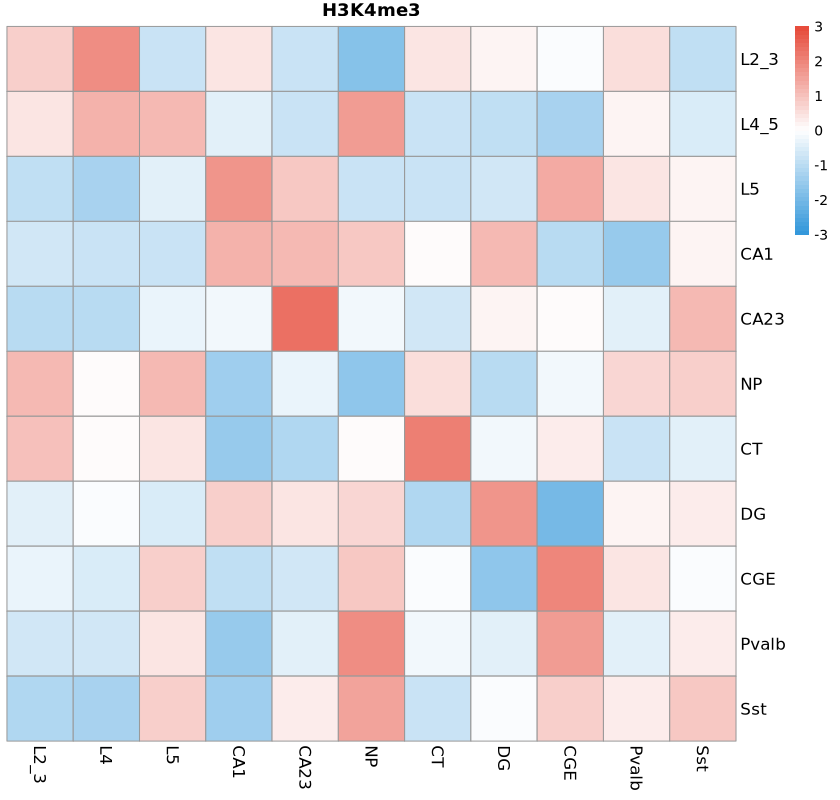

In [58]:
options(repr.plot.width = 8.4, repr.plot.height = 8, repr.plot.res = 100)
pheatmap(
  scaled_heatmap_matrix,
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  color = colorRampPalette(c("#3498db", "white", "#e74c3c"))(50),
  main = "H3K4me3",
  fontsize_row = 12,
  fontsize_col = 12,
  breaks = seq(-3, 3, length.out = 51)
)

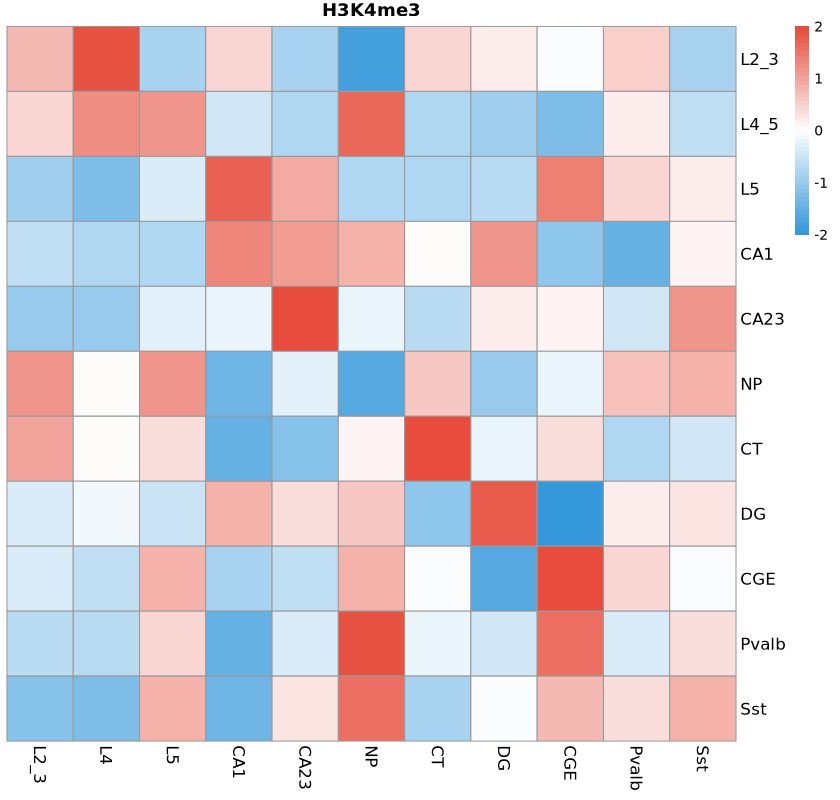

In [59]:
options(repr.plot.width = 8.4, repr.plot.height = 8, repr.plot.res = 100)
pheatmap(
  scaled_heatmap_matrix,
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  color = colorRampPalette(c("#3498db", "white", "#e74c3c"))(50),
  main = "H3K4me3",
  fontsize_row = 12,
  fontsize_col = 12,
  breaks = seq(-2, 2, length.out = 51)
)

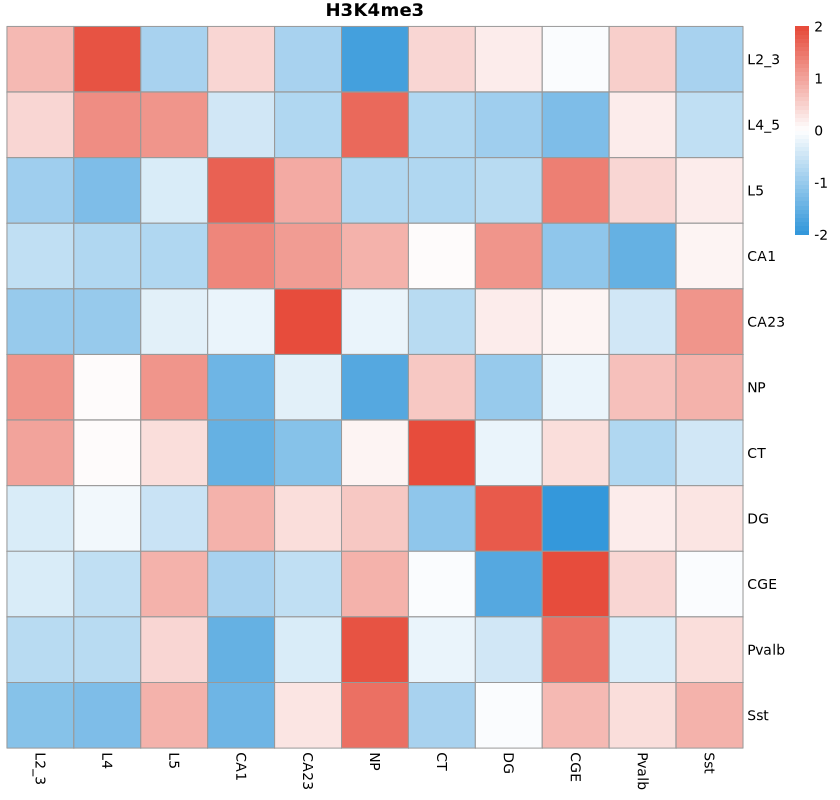

In [60]:
p1 <- pheatmap(
  scaled_heatmap_matrix,
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  color = colorRampPalette(c("#3498db", "white", "#e74c3c"))(50),
  main = "H3K4me3",
  fontsize_row = 10,
  fontsize_col = 10,
  breaks = seq(-2, 2, length.out = 51)
)

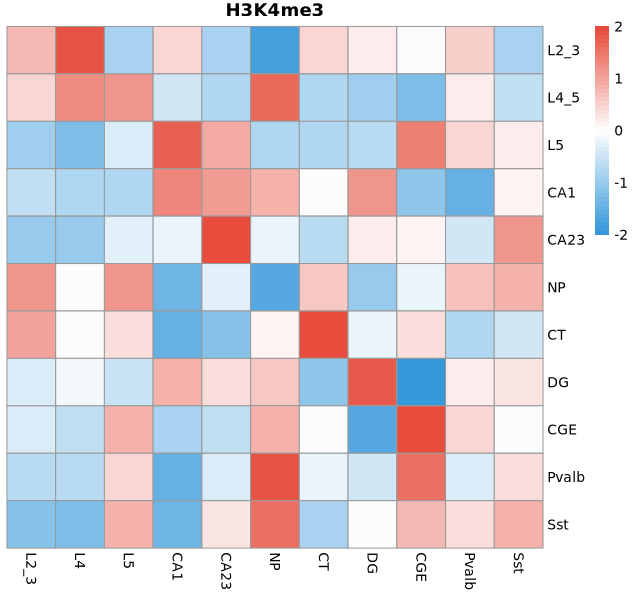

In [61]:
options(repr.plot.width = 6.4, repr.plot.height = 6, repr.plot.res = 100)
p1

In [ ]:
pdf("../../../output/01-youth/07-Histone/01-heatmap/09-H3K4me3_modification_in_hyperDHMR_merge_v3.pdf",width = 6.4,height = 6)
p1
dev.off()

png 
  2

In [ ]:
# Finished!